 12 April 2024 Week 2 Day 3

Scikit-Learn

Değişiklenler Arasındaki ilişkilerin Analizi ( Exploratory Data Analysis ) ( EDA )

Neden ilişki anlaizi?
* Değişkenleri arasındaki ilişkileri anlamak veri setinden değerli biligler elde etmemizi sağlar.
* Bu bilgiler iş kararları almak tahminler yapmak ve olayları açıklaamk için kullanılır.
* Farklı değişken türleri arasındaki ilişkileri incelemek için farklı yöntemler gereklidir.

Çaproz Tablolama ( Cross-tabulations)
* pandas.crıosstab() fonksiyonu ile oluşturulur
* ilki veya daha fazla kategorik değişkenler arasındaki ilişkiyi özetler
* Her hücre belirli bir kategori kombinasyonuna ait gözlem sayınıu gösterir.
* Örnek: Müşteri cinsiyeti ile satın alınan ürün kategorisi arasındaki ilşikiyi gösterir.

Gruplandırılmış istatiskiler
* pandas.groupby() fonksiyonu ile hesaplanır
* Kateogirk değişkenelere göre sayısal değişkenlerin özet istatistiklerini ( ortalama medyan toplam vb. ) gösterir.
* Örnek: Farklı müşteri segmentlerinin ortlama harcama tutarları.

Hipotez testleri - Ki-kare testi
* kaegorik değişkenler arasındaki bağımsızlığı test eder.
* Gözlenen frekanslar ile beklene frekanslar arasındaki farkı ölçer
* Formül: X^2 = Σ((O - E)^2 / E)
* X^2: Ki-kare istatistiği
* O: Gözlenen frekans
* E: Beklenen frekans
* Σ: Tüm hücreler için toplam
* Örnek: Müşteri cinsiyeti ile satın alınan ürün kategorisi arasındaki bağımsızlık testi.

Hipotez Testleri- ANOVA
* Sayısal bir değişkenin kategorik bir değişkene göre ortalamarını farklı olup olmadığını test eder.
* Gruplar arası ve gruplar için varyasyonu karşılatırır.
* Formül: F = Varyasyonlar arası / Varyasyonlar içi ( MST / MSE )
* F: ANOVA istatistiği
* MST: Gruplar arası ortalama kareler toplamı ( Mean Square Treatment )
* MSE: Gruplar içi ortalama kareler toplamı ( Mean Square Error )
* Anova'nın geçerli olabilmesi için azı varsayımlar sağlanması gekerir
* Varsayımlar:
  * Normal dağılımÇ: Ger grup içindeki verilerin normal dağılma sahip olmasıo
  * Varyans homojenliği grupların varyanslarının eşit olması
  * Bağımsızlık Gözlemlerin birbirinden bağımsız olması
* Kontrol yöntemleri
  * Normallik: shapiro-wilk testi, kolmogorov-smirnov testi, histogram, q-q grafiği
  * varyans homojenliği: Levene testi, Bartlett testi

ANOVA - post-hoct tesler
* anova da anlamlaı sonuç alınmadıoğında hangi gruplar arasında anlamlı fark olduğunu belirlemek için kullanılır.
* Tukey HSD testi, Bonferroni testi, Scheffe testi gibi yöntemler kullanılır.

ANOVA - etki ölçileri
* hipotez testinin sonuvlarıı pratik önenimi değerlendirmek için kullanılır.
* Örnekler etki büyüklüğü ( effect size ) Cohen's d, eta kare, omega kare gibi ölçüler kullanılır.

Sayısal değişkenler arasındakı ililkiler - Korelasyon ve Kovaryans
* korelasyon, iki sayısal değişken arasındaki doğrusal ilişkinin gücünü ve gücünü ölçer
  * Pearson korelasyonu: iki değişken arasındaki doğrusal ilişkiyi ölçer.
  * pearson korelasuyon katsayısı (r)
* Kovaryans, iki sayısal değişkenin bilirkte ne kadar değiştinin gösterir.

Sayısal değişkenler arasındaki ilişkiler - Kolerasyon matrisi görselleştirme
* Sayısal değikenler arasındaki korelasyonları bir matrix şeklinde gösterir.
* Isı haritası heatmap ilke görserlleştirerek yorumlanması kolaylaştılır.

Sayısal değişkenler arasındaki ilişkiler - Regresyon analizi
* sayısal dbir bağımı değişken ile bir veya daha fakza bapımsız arasubdakji ililkşiyi inceler.
* Türker:
  * Doğrusal regresyon: bağımlı değişken ile bağımsız değişkenler arasındaki doğrusal ilişkiyi inceler.
  * Lojistik regresyon: bağımlı değişkenin ikili ( binary ) olduğu durumlarda kullanılır.

Regresyon abalizi - varysayım kontrolleri
* regresyon modelini geçerli olabilmesi için baız varsayamları sağlaması gerekir.
* Varsayımlar
  * Doğrusallık
  * hata terimlerini mnormlaliği
  * hata terimlerini varyans homojenliği ( homoskedastisite)
  * hata terimlerinin bağımsızlığı

Regresyon abalizi - etkileşim terimleri
Regresyon analizi - karışıklık terimleri

Diğer sınıflandırma algorileri ile ilişki analizi ( eğer gerekirse)
* logistik regresyon dışında dipğer sınıflandırma algoritmaları ( örneğim karar ağalçlaru destek verktör makineleri ) kullanularaj da değişken arasındaki ilişkikleri inceleyebilir.









# Titanic - Machine Learning from Disaster

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [15]:
# Load the dataset
df = pd.read_csv('dataset/train.csv')

# Veri setini incele
print('Veri Seti Bilgileri:\n', df.info())
print('\nİlk 5 Satır:\n', df.head())
print('\nDeğişkenlerin İstatistiksel Özeti:\n', df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Veri Seti Bilgileri:
 None

İlk 5 Satır:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5        

Cross Tabulation

In [16]:
# Cinsiyet ve Hayatta Kalma İlişkisi
capraz_tablo_cinsiyet_hayatta_kalma = pd.crosstab(df['Sex'], df['Survived'])
print('\nCinsiyet ve Hayatta Kalma İlişkisi:\n', capraz_tablo_cinsiyet_hayatta_kalma)


Cinsiyet ve Hayatta Kalma İlişkisi:
 Survived    0    1
Sex               
female     81  233
male      468  109

Yolcu Sınıfı ve Hayatta Kalma İlişkisi:
 Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

Yolcu kardeş ve Hayatta Kalma İlişkisi:
 Survived    0    1
SibSp             
0         398  210
1          97  112
2          15   13
3          12    4
4          15    3
5           5    0
8           7    0

Cinsiyet ve Yolcu Sınıfı İlişkisi:
 Pclass    1    2    3
Sex                  
female   94   76  144
male    122  108  347


In [17]:
# Yolcu Sınıfı ve Hayatta Kalma İlişkisi
capraz_tablo_pclass_hayatta_kalma1 = pd.crosstab(df['Pclass'], df['Survived'])
print('\nYolcu Sınıfı ve Hayatta Kalma İlişkisi:\n', capraz_tablo_pclass_hayatta_kalma1)


Yolcu Sınıfı ve Hayatta Kalma İlişkisi:
 Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


In [18]:
# Yolcu Kardeş Sayısı ve Hayatta Kalma İlişkisi
capraz_tablo_pclass_hayatta_kalma2 = pd.crosstab(df['SibSp'], df['Survived'])
print('\nYolcu kardeş ve Hayatta Kalma İlişkisi:\n', capraz_tablo_pclass_hayatta_kalma2)


Yolcu kardeş ve Hayatta Kalma İlişkisi:
 Survived    0    1
SibSp             
0         398  210
1          97  112
2          15   13
3          12    4
4          15    3
5           5    0
8           7    0


In [19]:
# Cinsiyet ve Yolcu Sınıfı İlişkisi
capraz_tablo_cinsiyet_pclass = pd.crosstab(df['Sex'], df['Pclass'])
print('\nCinsiyet ve Yolcu Sınıfı İlişkisi:\n', capraz_tablo_cinsiyet_pclass)


Cinsiyet ve Yolcu Sınıfı İlişkisi:
 Pclass    1    2    3
Sex                  
female   94   76  144
male    122  108  347


In [ ]:
#   Cinsiyete göre yaş ve bilet ücreti ortalamaları
ortalama_tablo_cinsiyet = df.groupby('Sex')[['Age', 'Fare']].mean()
print('\nCinsiyete Göre Yaş ve Bilet Ücreti Ortalamaları:\n', ortalama_tablo_cinsiyet)

#   Yolcu sınıfına göre yaş ve bilet ücreti ortalamaları
ortalama_tablo_pclass = df.groupby('Pclass')[['Age', 'Fare']].mean()
print('\nYolcu Sınıfına Göre Yaş ve Bilet Ücreti Ortalamaları:\n', ortalama_tablo_pclass)

Mean

In [21]:
#   Cinsiyete göre yaş ve bilet ücreti ortalamaları
ortalama_tablo_cinsiyet = df.groupby('Sex')[['Age', 'Fare']].mean()
print('\nCinsiyete Göre Yaş ve Bilet Ücreti Ortalamaları:\n', ortalama_tablo_cinsiyet)


Cinsiyete Göre Yaş ve Bilet Ücreti Ortalamaları:
               Age       Fare
Sex                         
female  27.915709  44.479818
male    30.726645  25.523893


In [22]:
#   Yolcu sınıfına göre yaş ve bilet ücreti ortalamaları
ortalama_tablo_pclass = df.groupby('Pclass')[['Age', 'Fare']].mean()
print('\nYolcu Sınıfına Göre Yaş ve Bilet Ücreti Ortalamaları:\n', ortalama_tablo_pclass)


Yolcu Sınıfına Göre Yaş ve Bilet Ücreti Ortalamaları:
               Age       Fare
Pclass                      
1       38.233441  84.154687
2       29.877630  20.662183
3       25.140620  13.675550


Ki-kare Testi

In [23]:
#   Ki-kare Testi (Cinsiyet ve Hayatta Kalma)
ki2, p, serbestlik_derecesi, beklenen = stats.chi2_contingency(capraz_tablo_cinsiyet_hayatta_kalma)
print('\nKi-kare Testi (Cinsiyet ve Hayatta Kalma):')
print('Ki-kare istatistiği:', ki2)
print('p-değeri:', p)


Ki-kare Testi (Cinsiyet ve Hayatta Kalma):
Ki-kare istatistiği: 260.71702016732104
p-değeri: 1.1973570627755645e-58


In [24]:
#   Ki-kare Testi (Sınıf Sayısı ve Hayatta Kalma)
ki2, p, serbestlik_derecesi, beklenen = stats.chi2_contingency(capraz_tablo_pclass_hayatta_kalma1)
print('\nKi-kare Testi (Sınıf ve Hayatta Kalma):')
print('Ki-kare istatistiği:', ki2)
print('p-değeri:', p)


Ki-kare Testi (Sınıf ve Hayatta Kalma):
Ki-kare istatistiği: 102.88898875696056
p-değeri: 4.549251711298793e-23


In [25]:
#   Ki-kare Testi (Kardeş Sayısı ve Hayatta Kalma)
ki2, p, serbestlik_derecesi, beklenen = stats.chi2_contingency(capraz_tablo_pclass_hayatta_kalma2)
print('\nKi-kare Testi (Kardeş SAyısı ve Hayatta Kalma):')
print('Ki-kare istatistiği:', ki2)
print('p-değeri:', p)


Ki-kare Testi (Kardeş SAyısı ve Hayatta Kalma):
Ki-kare istatistiği: 37.2717929152043
p-değeri: 1.5585810465902147e-06


ANOVA - Testi

In [26]:
#   ANOVA (Yolcu Sınıfı ve Bilet Ücreti)
gruplar = []
for pclass in df['Pclass'].unique():
    gruplar.append(df[df['Pclass'] == pclass]['Fare'])

fvalue, pvalue = stats.f_oneway(*gruplar)
print('\nANOVA (Yolcu Sınıfı ve Bilet Ücreti):')
print('F-değeri:', fvalue)
print('p-değeri:', pvalue)


ANOVA (Yolcu Sınıfı ve Bilet Ücreti):
F-değeri: 242.34415651744806
p-değeri: 1.0313763209142051e-84


## Sayısal Değişkenler Arasındaki İlişkiler
Korelasyon Matrisi


Korelasyon Matrisi:
              Age    Pclass      Fare     SibSp     Parch
Age     1.000000 -0.369226  0.096067 -0.308247 -0.189119
Pclass -0.369226  1.000000 -0.549500  0.083081  0.018443
Fare    0.096067 -0.549500  1.000000  0.159651  0.216225
SibSp  -0.308247  0.083081  0.159651  1.000000  0.414838
Parch  -0.189119  0.018443  0.216225  0.414838  1.000000


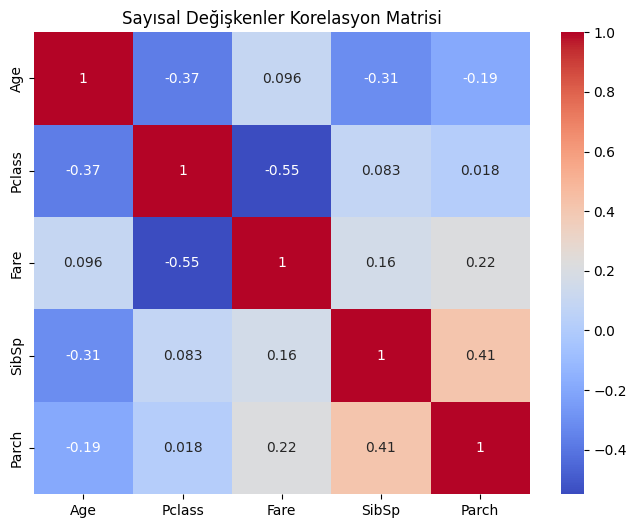

In [27]:
#Sayısal Değişkenler Arasındaki İlişkiler
#   Korelasyon Matrisi
korelasyon_matrisi = df[['Age',"Pclass", 'Fare', 'SibSp', 'Parch']].corr()  # Sayısal sütunları seçin
print('\nKorelasyon Matrisi:\n', korelasyon_matrisi)

#   Korelasyon Matrisi Görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm')
plt.title('Sayısal Değişkenler Korelasyon Matrisi')
plt.show()

Regresyon Analizi


In [28]:
#   Regresyon Analizi (Yaş ve Bilet Ücreti)
#   (Bu örnekte çok anlamlı bir ilişki olmayabilir, amaç yöntemi göstermek)
from sklearn.linear_model import LinearRegression

df_regresyon = df[['Age', 'Fare']].dropna()  # Eksik değerleri temizle
model = LinearRegression()
model.fit(df_regresyon[['Age']], df_regresyon['Fare'])
print('\nRegresyon Analizi (Yaş ve Bilet Ücreti):')
print('Katsayı:', model.coef_)
print('Kesim:', model.intercept_)


Regresyon Analizi (Yaş ve Bilet Ücreti):
Katsayı: [0.34996368]
Kesim: 24.300901449288645


## Kategorik Bağımlı Değişken İlişkileri

Lojistik Regresyon

In [29]:
#Kategorik Bağımlı Değişken İlişkileri
#   Logistik Regresyon (Hayatta Kalma ve Cinsiyet)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#   Cinsiyeti sayısal hale getir
le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])

#   Eğitim ve test kümelerine ayır
df_logreg = df[['Survived', 'Sex_encoded']].dropna()
X = df_logreg[['Sex_encoded']]
y = df_logreg['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#   Modeli eğit
model_logreg = LogisticRegression()
model_logreg.fit(X_train, y_train)

print('\nLogistik Regresyon (Hayatta Kalma ve Cinsiyet):')
print('Katsayı:', model_logreg.coef_)
print('Kesim:', model_logreg.intercept_)


Logistik Regresyon (Hayatta Kalma ve Cinsiyet):
Katsayı: [[-2.42968682]]
Kesim: [0.98953392]
